### Indices.ipynb
Códigos para graficar series de tiempo de índices
* un plot para cada índice, con n lineas de n sitios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data_path = '/home/camilo/figuras_mauro/data/cleaned_indexes.csv'
df = pd.read_csv(data_path)
df.head()

,datetime,id,fecha,hora,site,file,MEANt,VARt,Ht,MEANf,VARf,Hf,SKEWf,KURTf,ACI,NDSI,ADI,AEI,BI,H
0,2023-09-28 00:00:00,SMM09353,20230928,00:00:00,P15_SMM09353,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,1.886608e-19,4.442061e-06,0.990822,0.000056,5.521898e-09,0.713048,2.979317,11.379908,297.205218,-0.786162,2.078736,0.020504,28.838343,0.706504
1,2023-09-28 00:00:00,SMM09520,20230928,00:00:00,P36_SMM09520,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,5.142491e-20,2.983885e-05,0.957052,0.000189,2.211001e-08,0.883924,0.787159,3.413339,300.220489,0.465466,2.062933,0.067418,156.819991,0.845961
2,2023-09-28 00:00:00,SMM09557,20230928,00:00:00,P04_SMM09557,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,3.978299e-20,8.943558e-07,0.984667,0.000037,3.603905e-10,0.918459,2.145733,7.700871,297.069236,0.078992,2.079441,0.000513,30.001011,0.904376
3,2023-09-28 00:00:00,SMM09245,20230928,00:00:00,P40_SMM09245,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,-3.762422e-20,9.977210e-05,0.709976,0.000298,9.683808e-08,0.795403,2.198737,8.184640,336.810329,0.127292,1.942652,0.290429,73.972771,0.564717
4,2023-09-28 00:00:00,SMM09565,20230928,00:00:00,P34_SMM09565,/home/msg/Escritorio/Camilo_Behrens/20230928/P...,-4.245832e-19,1.081642e-04,0.950643,0.000333,1.017159e-07,0.812370,2.247418,8.606597,307.235421,0.589434,2.078422,0.023275,96.947049,0.772274


In [3]:
from scipy.ndimage import gaussian_filter1d

In [4]:
indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']

In [ ]:

# Opcional: Suavisado usando filtro Gaussiano
def suaviza_serie(serie, sigma=2):
    # Puedes ajustar sigma para controlar el nivel de suavisado
    return gaussian_filter1d(serie, sigma=sigma)

# Agrupar por site y graficar cada índice
for indice in indices:
    plt.figure(figsize=(14, 7))
    
    # Grafica una línea por cada site
    for site, group in df.groupby('site'):
        # Ordena por datetime
        group_sorted = group.sort_values('datetime')
        x = group_sorted['datetime']
        y = group_sorted[indice]
        
        # Aplica suavisado
        y_suave = suaviza_serie(y.values)
        
        # Grafica
        plt.plot(x, y_suave, label=site)
    
    plt.title(f'Serie de Tiempo de {indice} por Site')
    plt.xlabel('Fecha')
    plt.ylabel(indice)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


KeyboardInterrupt: 

Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 10135 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 10135 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 10135 ticks (

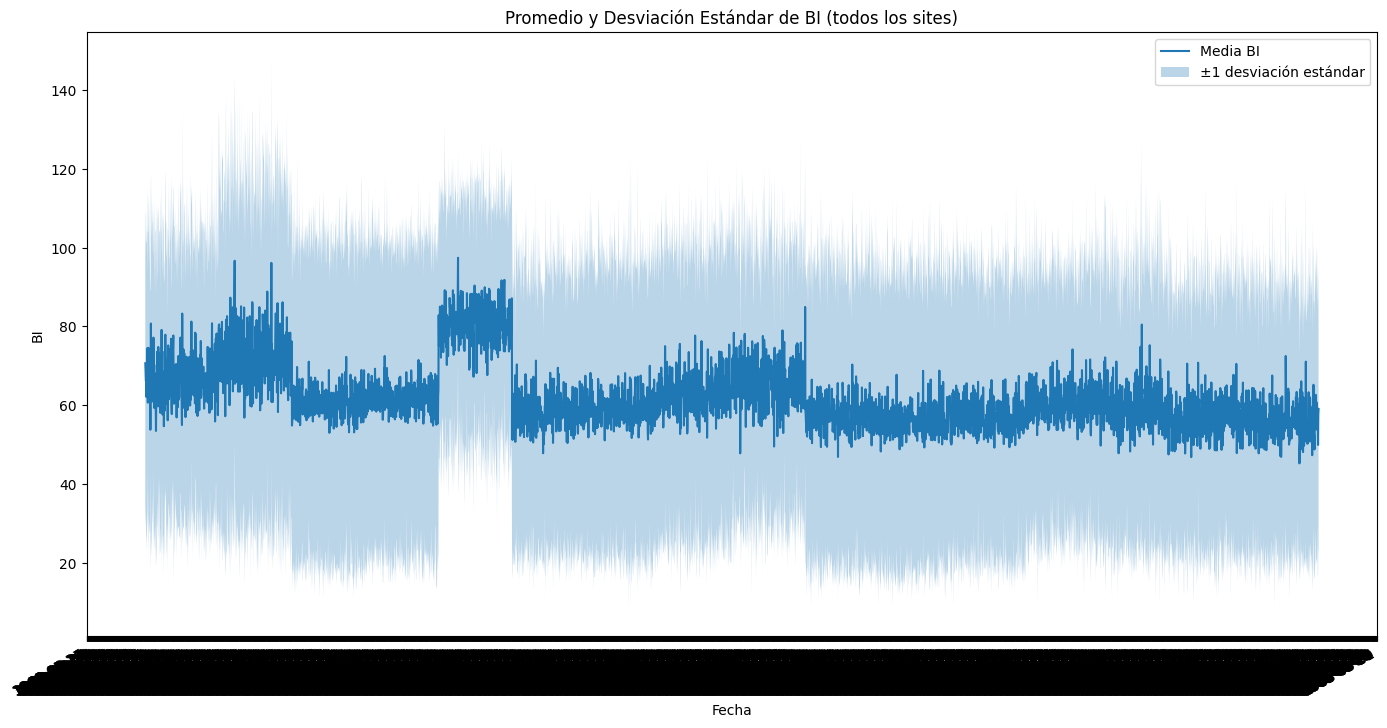

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Índice que quieres graficar
indice_a_graficar = 'BI'  # Cambia esto por el índice deseado

plt.figure(figsize=(14, 7))

# Agrupar por datetime y calcular media y desviación estándar
grouped = df.groupby('datetime')[indice_a_graficar].agg(['mean', 'std']).reset_index()

x = grouped['datetime']
y_mean = grouped['mean']
y_std = grouped['std']

plt.plot(x, y_mean, label=f'Media {indice_a_graficar}')
plt.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.3, label='±1 desviación estándar')

plt.title(f'Promedio y Desviación Estándar de {indice_a_graficar} (todos los sites)')
plt.xlabel('Fecha')
plt.ylabel(indice_a_graficar)
plt.legend()
plt.tight_layout()

# Escalado del eje x con ticks y etiquetas
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0,24,12)))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30, ha='right')

plt.show()


/tmp/ipykernel_40078/487262223.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
/tmp/ipykernel_40078/487262223.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend(

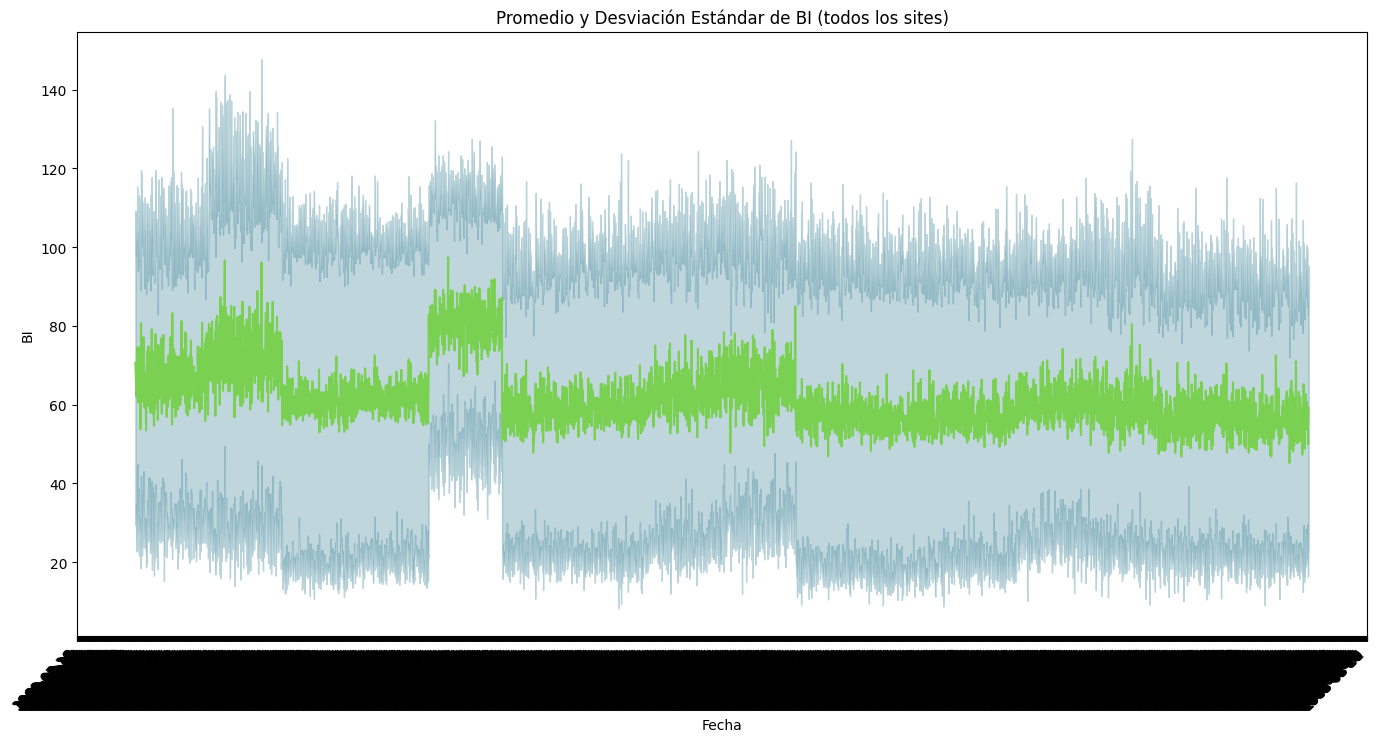

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import numpy as np

indice_a_graficar = 'BI'  # Cambia por el índice que quieras graficar

plt.figure(figsize=(14, 7))

# Calcular media y desviación estándar por datetime
grouped = df.groupby('datetime')[indice_a_graficar].agg(['mean', 'std']).reset_index()

x = grouped['datetime']
y_mean = grouped['mean']
y_std = grouped['std']

# Color viridis para la línea y el relleno
cmap = cm.get_cmap('viridis')
line_color = cmap(0.8)
fill_color = cmap(0.4)

plt.plot(x, y_mean, color=line_color)
plt.fill_between(x, y_mean - y_std, y_mean + y_std, color=fill_color, alpha=0.3)

plt.title(f'Promedio y Desviación Estándar de {indice_a_graficar} (todos los sites)')
plt.xlabel('Fecha')
plt.ylabel(indice_a_graficar)
plt.tight_layout()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Marca mayor cada 1 día
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0]))  # Marca menor a la medianoche
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Etiqueta solo la fecha
plt.xticks(rotation=45, ha='right')

plt.legend().set_visible(False)  # Quitar leyenda

plt.show()


/tmp/ipykernel_40078/618581542.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 5068 ticks ([-230.0, ..., 4837.0]), which

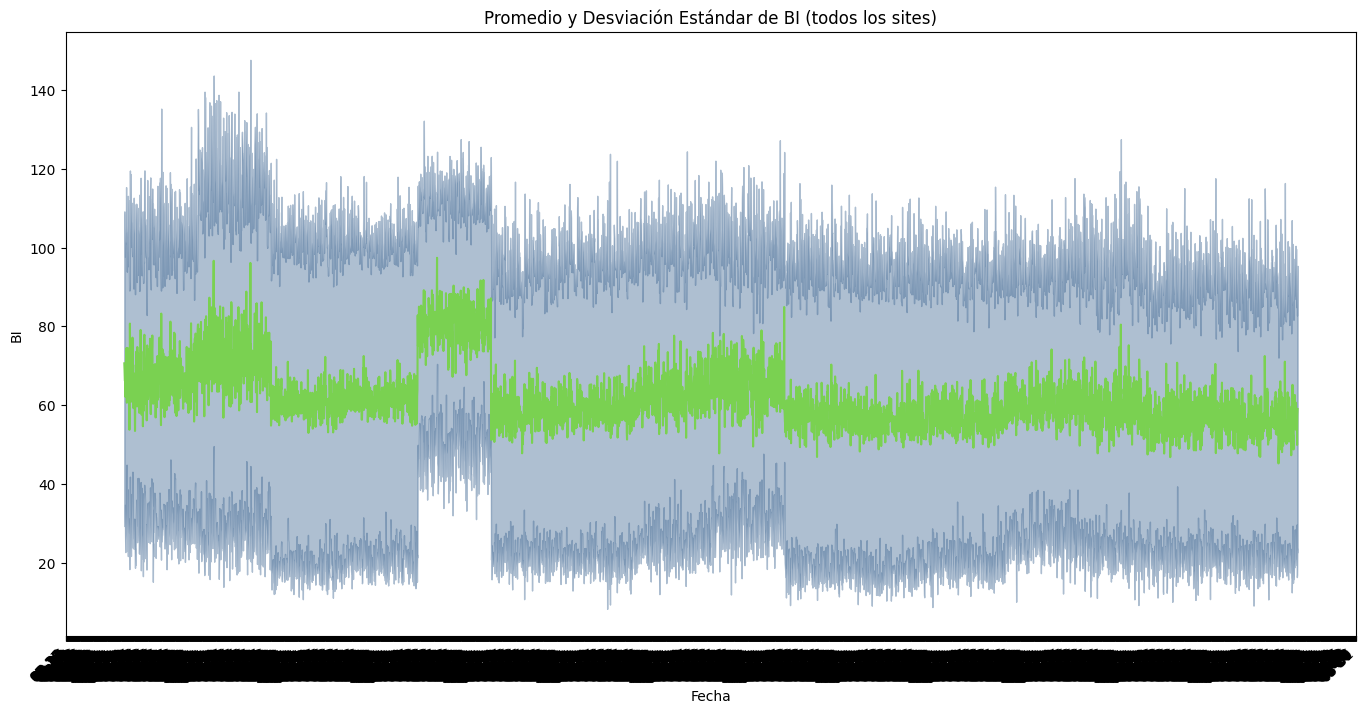

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from matplotlib.ticker import NullLocator

indice_a_graficar = 'BI'  # Cambia por el índice que quieras graficar

plt.figure(figsize=(14, 7))

# Agrupar por datetime y calcular media y desviación estándar
grouped = df.groupby('datetime')[indice_a_graficar].agg(['mean', 'std']).reset_index()

x = grouped['datetime']
y_mean = grouped['mean']
y_std = grouped['std']

# Paleta viridis para línea y área
cmap = cm.get_cmap('viridis')
line_color = cmap(0.8)
fill_color = cmap(0.3)

plt.plot(x, y_mean, color=line_color)
plt.fill_between(x, y_mean - y_std, y_mean + y_std, color=fill_color, alpha=0.4)

plt.title(f'Promedio y Desviación Estándar de {indice_a_graficar} (todos los sites)')
plt.xlabel('Fecha')
plt.ylabel(indice_a_graficar)
plt.tight_layout()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Una marca cada día
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_minor_locator(NullLocator())  # Sin marcas menores

plt.xticks(rotation=45, ha='right')

plt.show()



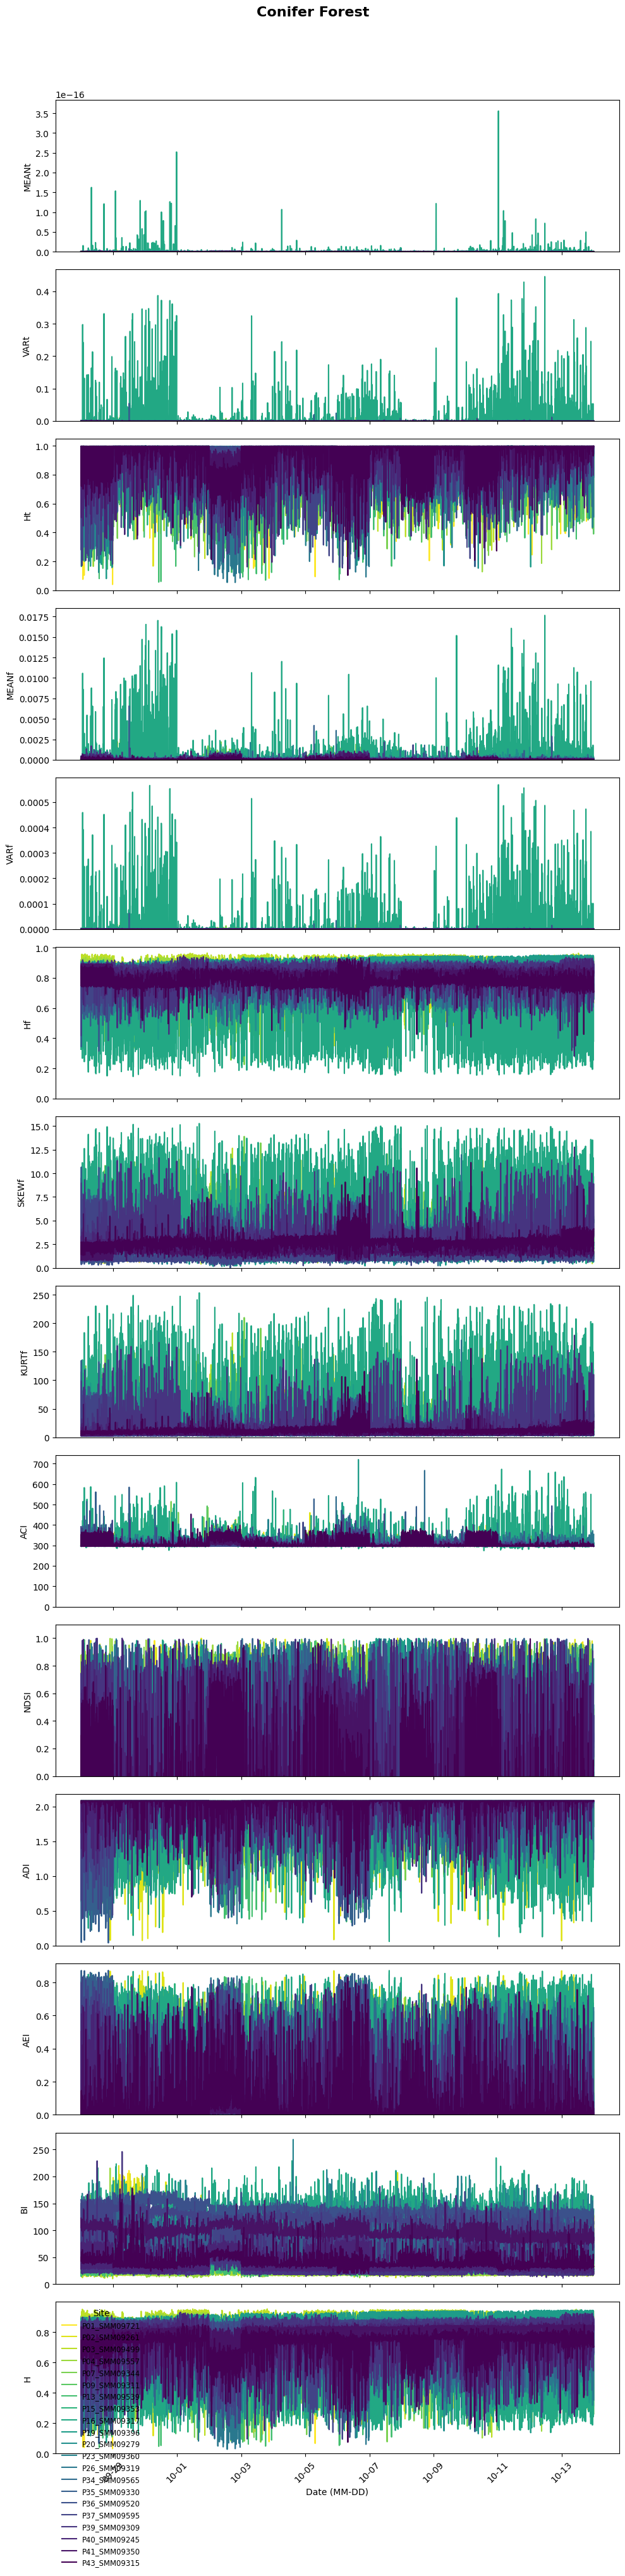

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Supongamos que tu df se llama df
df['datetime'] = pd.to_datetime(df['datetime'])

cols = df.columns[df.columns.get_loc('MEANt'):]

grouped = df.groupby(['datetime', 'site'])[cols].agg(['mean', 'std']).reset_index()

n = len(cols)
fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
fig.suptitle('Conifer Forest', fontsize=16, fontweight='bold')

sites = grouped['site'].unique()
colors = plt.cm.viridis_r(np.linspace(0, 1, len(sites)))

if n == 1:
    axes = [axes]

for i, col in enumerate(cols):
    ax = axes[i]
    for j, site in enumerate(sites):
        data = grouped[grouped['site'] == site]
        x = data['datetime']
        y = data[(col, 'mean')]
        yerr = data[(col, 'std')]

        ax.plot(x, y, label=site, color=colors[j])
        ax.fill_between(x, y - yerr, y + yerr, color=colors[j], alpha=0.3)

    ax.set_ylabel(col)
    ax.set_ylim(bottom=0)

# Configurar formato de fecha en eje x
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[-1].set_xlabel('Date (MM-DD)')
axes[-1].tick_params(axis='x', rotation=45)
axes[-1].legend(title='Site', loc='upper left', fontsize='small', frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



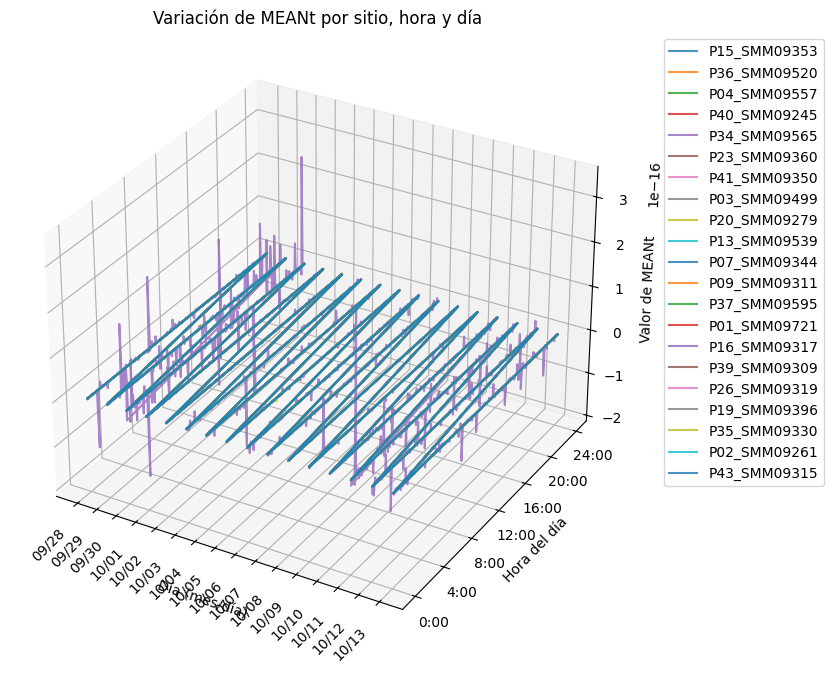

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



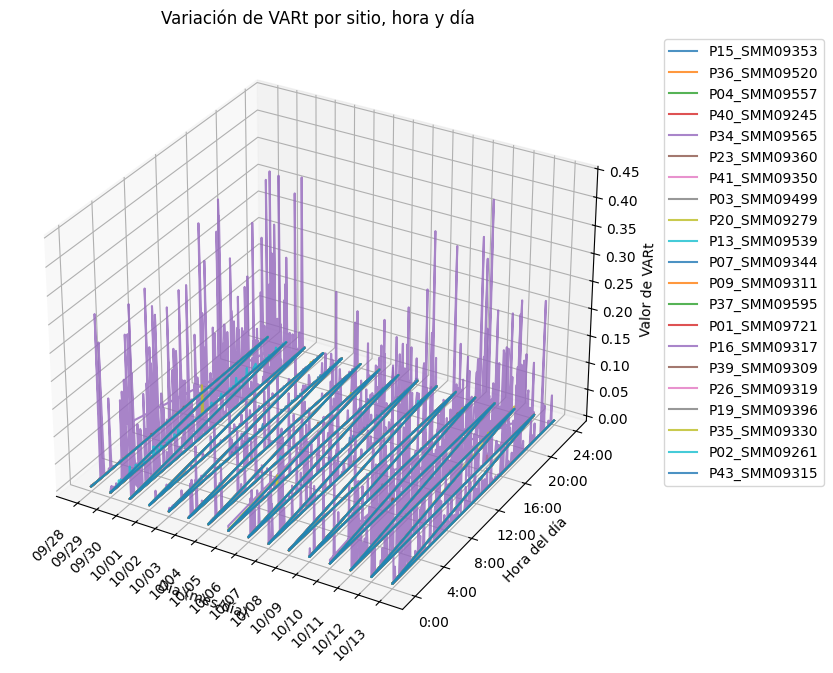

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



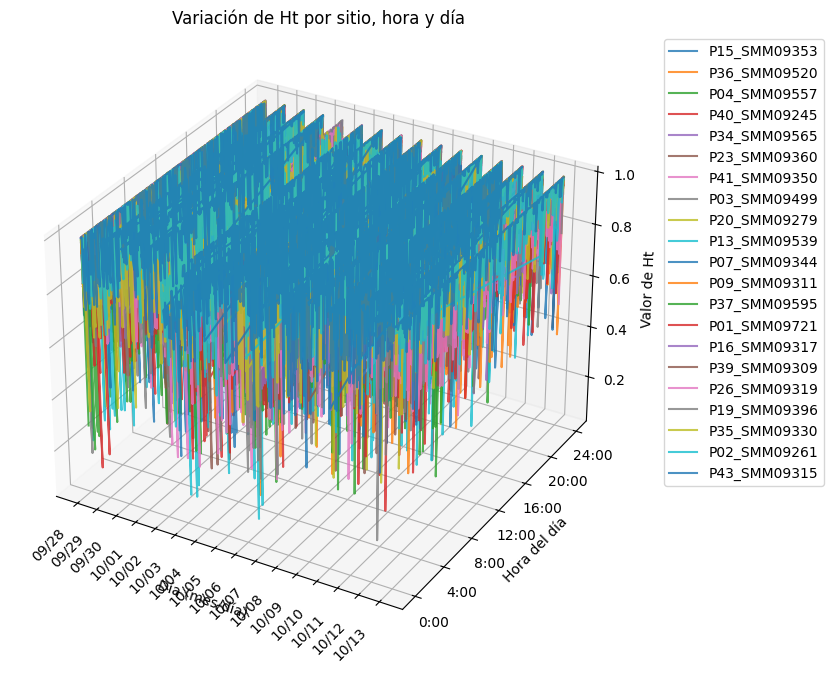

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



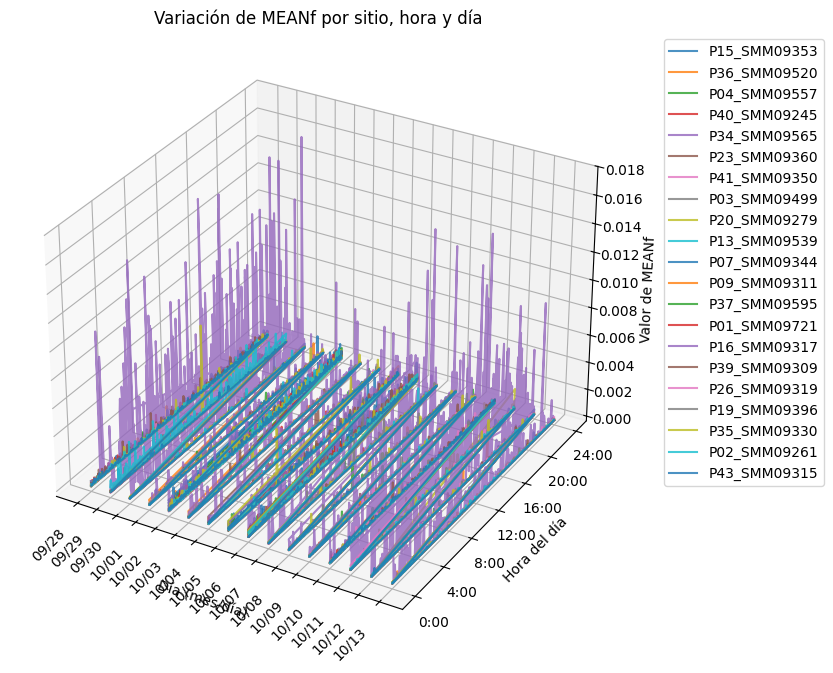

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



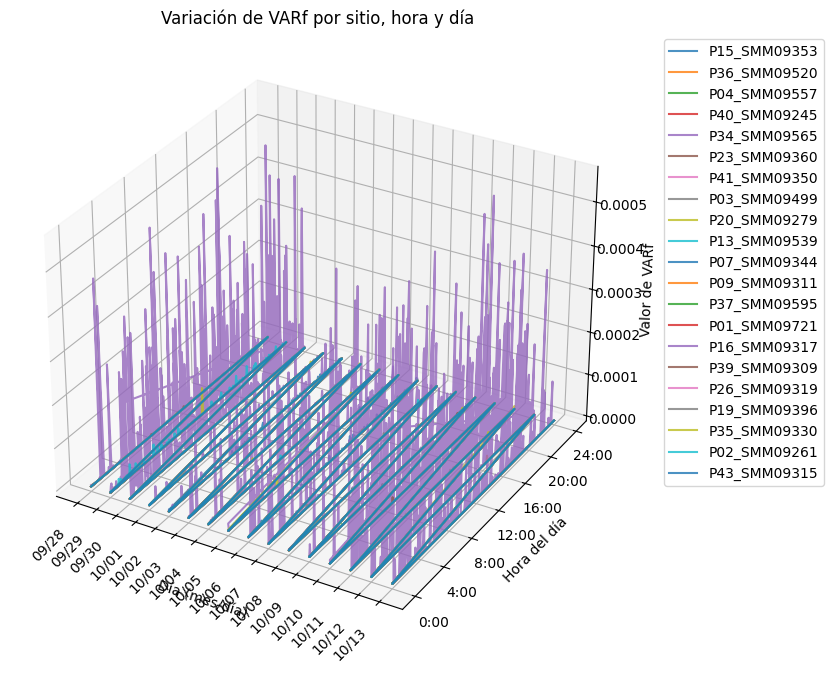

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



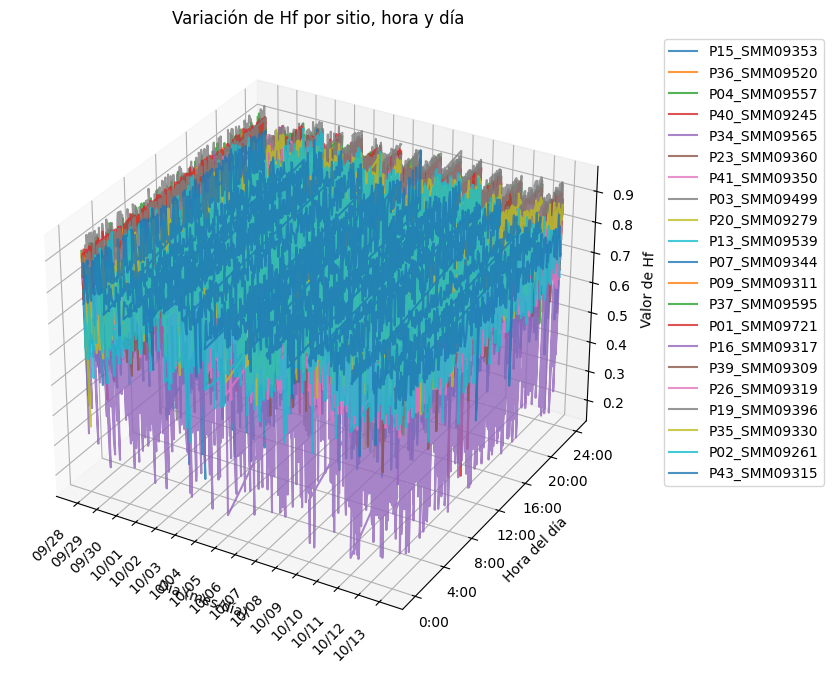

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



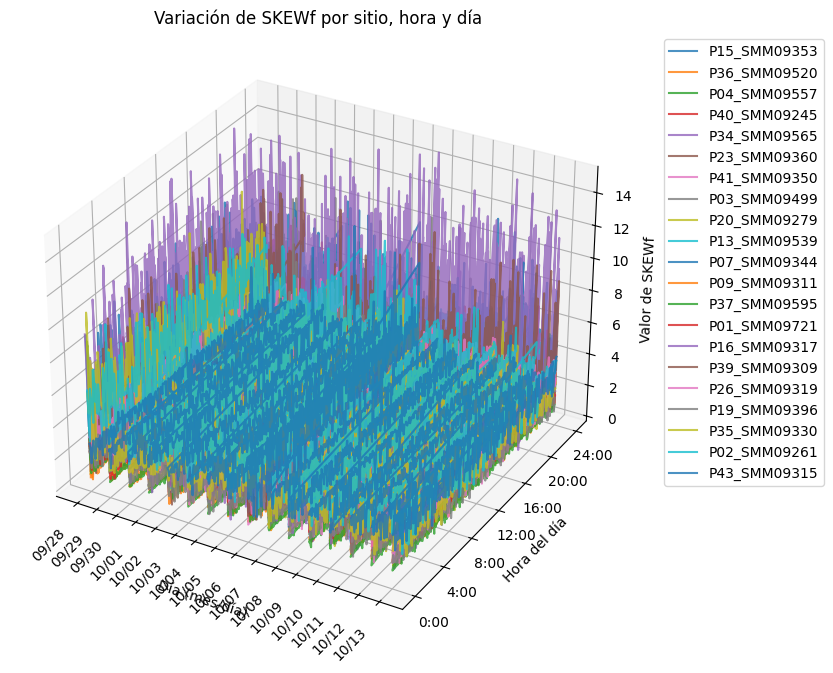

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



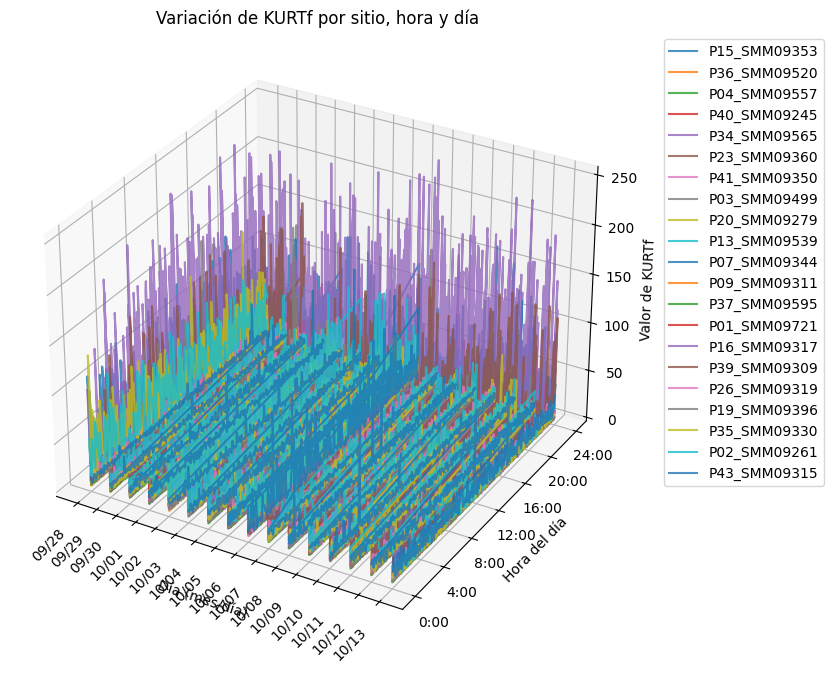

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



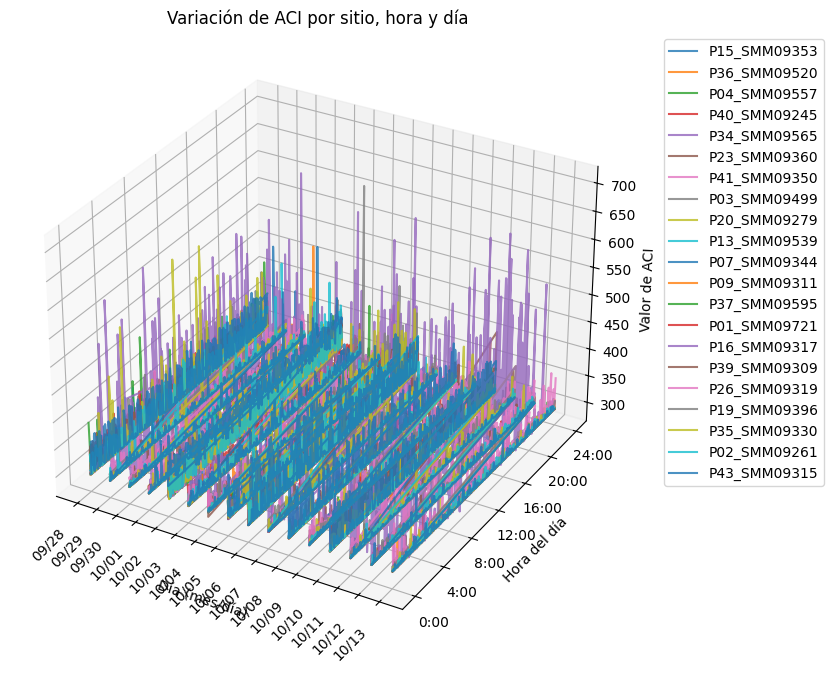

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



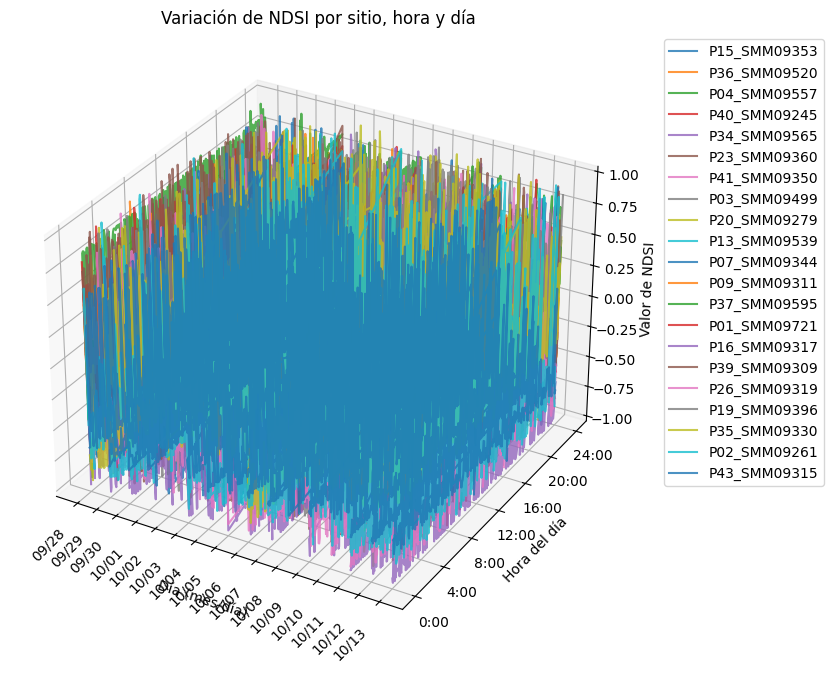

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



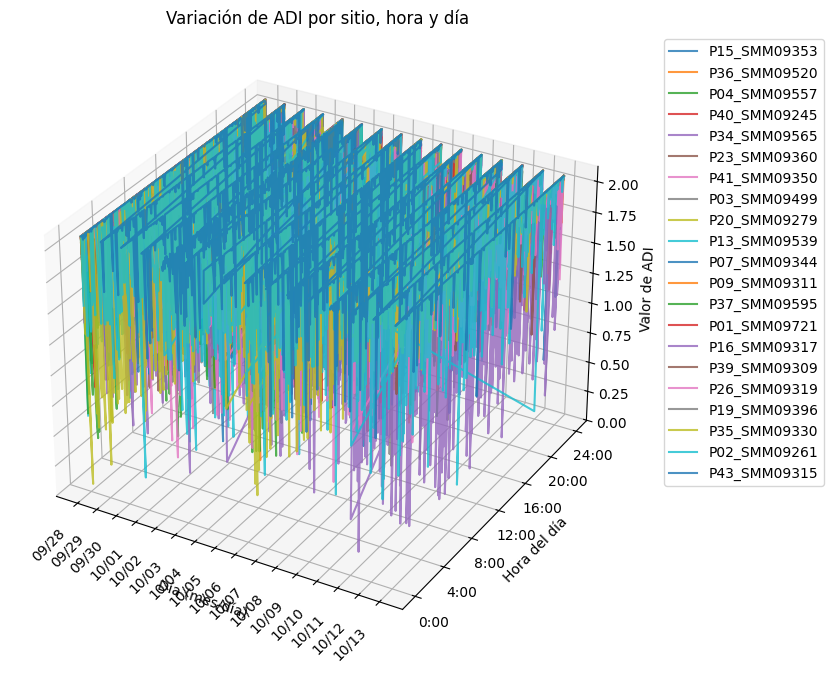

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



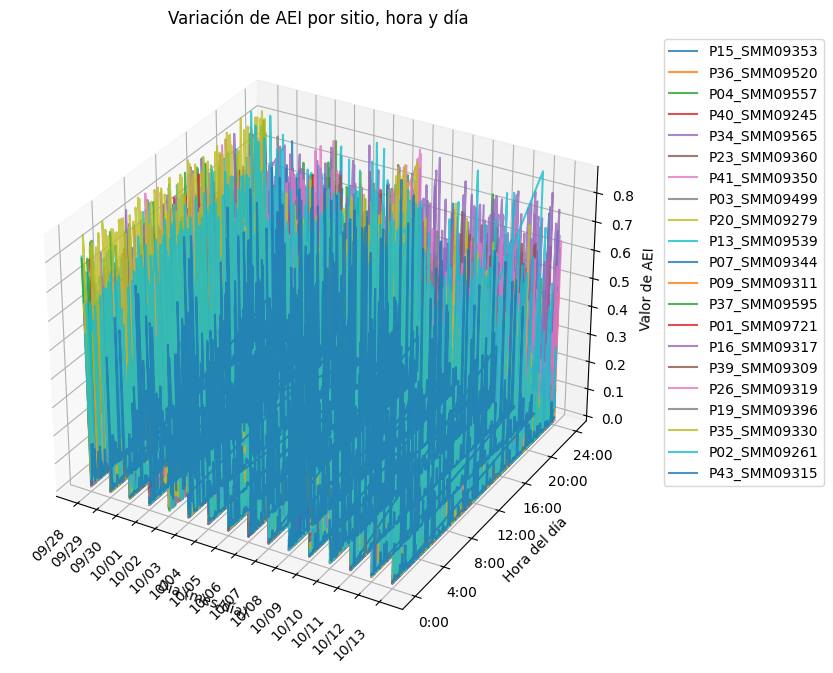

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



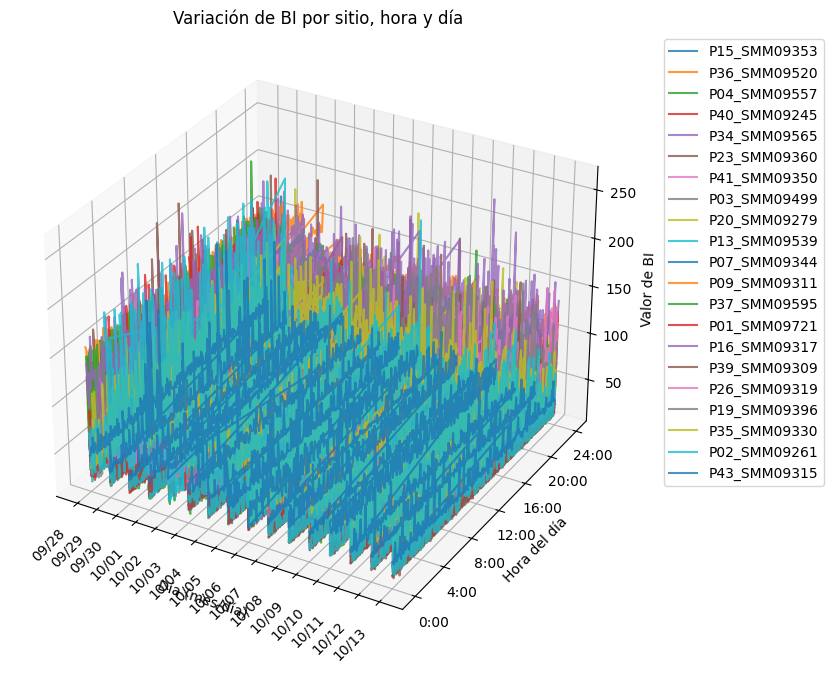

/tmp/ipykernel_40078/4058375357.py:53: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



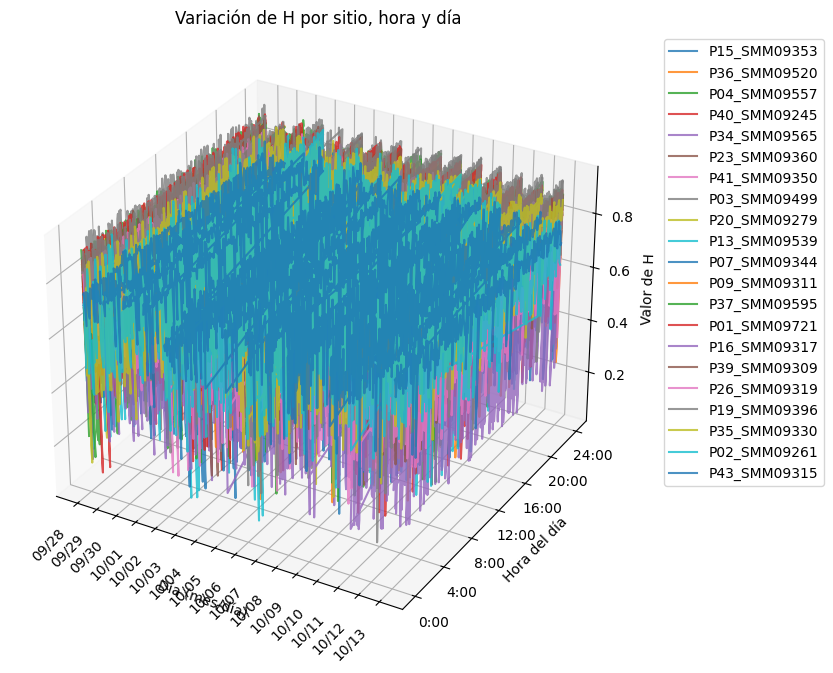

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib import cm

# Configuración inicial
df['datetime'] = pd.to_datetime(df['datetime'])
df['dia_str'] = df['datetime'].dt.strftime('%m/%d')  # Eje X categórico (mes/día)
df['hora'] = df['datetime'].dt.hour + df['datetime'].dt.minute/60  # Eje Y (0-24)
indices = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 
           'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'H']

# Crear una figura 3D por índice
for idx in indices:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Mapear días a posiciones numéricas (para eje X)
    dias_unicos = df['dia_str'].unique()
    dia_to_num = {dia: i for i, dia in enumerate(dias_unicos)}
    df['dia_num'] = df['dia_str'].map(dia_to_num)
    
    # Graficar cada site como una línea 3D
    for site in df['site'].unique():
        df_site = df[df['site'] == site]
        ax.plot(
            df_site['dia_num'],          # Eje X (día)
            df_site['hora'],             # Eje Y (hora)
            df_site[idx],                # Eje Z (índice)
            label=site,
            alpha=0.8,
            linewidth=1.5
        )
    
    # Personalizar ejes
    ax.set_xlabel('Día (mes/día)')
    ax.set_ylabel('Hora del día')
    ax.set_zlabel(f'Valor de {idx}')
    ax.set_title(f'Variación de {idx} por sitio, hora y día')
    
    # Etiquetas del eje X (días)
    ax.set_xticks(list(dia_to_num.values()))
    ax.set_xticklabels(dia_to_num.keys(), rotation=45, ha='right')
    
    # Rango del eje Y (horas)
    ax.set_yticks(np.arange(0, 25, 4))  # Cada 4 horas
    ax.set_yticklabels([f"{int(h)}:00" for h in np.arange(0, 25, 4)])
    
    # Leyenda fuera del gráfico
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f'grafico_3d_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()